# Notebook 04 · Independent Validation Against Photo-Interpreted Reference Plots

Every accuracy number in notebooks `01b`, `02` and `03` measures **agreement with
the training target** (Copernicus CLMS for Milan, GHSL for Hanoi/HCMC) — not
correctness. This notebook scores the already-produced rasters against an
*independent* reference: 450 plots per city, photo-interpreted in Google Earth Pro
on 2018 imagery.

It reads existing outputs only. It retrains nothing, touches no Earth Engine, and
modifies no other notebook.

---

## Geometry: one plot ↔ one pixel

`ua_size_m = 10` — each plot is a **10 m × 10 m unit area, exactly one map pixel**.
The `3x3` grid subdivides *that pixel* into nine ~3.33 m sub-cells, each visually
interpreted to a land-cover code. (`cell_coverage_m = 10` is the coverage of the
whole unit area, not of one cell.)

| | extent | subdivision |
|---|---|---|
| reference plot | 10 m × 10 m | 9 sub-cells of ~3.33 m |
| map pixel | 10 m × 10 m | — |

So the correct pairing is the **single map pixel containing the plot**. There is no
support mismatch, and no neighbourhood aggregation is justified.

## The reference is a binomial estimate, not continuous truth

`ref_imd = 100 × n_impervious / n_cells_kept` takes only 10 values (0, 11.1, … 100),
because it is 9 binary cells. Formally it is a 9-draw sample of the pixel's true
impervious fraction *p*: **unbiased** (E[k/9] = p) but noisy, with standard error
`sqrt(p(1-p)/9)` — up to **16.7 pp** at p = 0.5, and 0 at p = 0 or 1.

Two consequences drive this notebook's design:

- Because the estimator is unbiased, **bias and correlation are estimated correctly**
  despite the discretisation. Discreteness itself is harmless; the sample size of 9
  is what costs precision.
- RMSE against this reference is **not** map error — it is
  `sqrt(map_error² + reference_noise²)`. That inflation is large and quantifiable, so
  Table 1 reports a noise-corrected RMSE alongside the raw one.

## `ref_label` is the stratum, not the truth

`ref_label` (IMD_Class_0..5, 75 plots each) records how the sample was *drawn* — from
CLMS/GHSL. Validating against it would just re-measure agreement with the map under
test. It is used here **only** for the stratification-balance printout.

## What to expect

A **ceiling / indistinguishability** result rather than a ranking: all Milan variants
sit within ~1.4 RMSE of each other, and CLMS — the product these models were trained
to reproduce — scores no better than they do. That is why the paired tests and
bootstrap CIs below are load-bearing rather than decorative.

In [19]:
# ── Interpreter + PROJ check -- RUN THIS FIRST ──────────────────────────
# Two environment problems on this machine, both fatal to the cells below:
#
# 1. Wrong kernel. C:\Python312 is on PATH and has no `ee`/`geemap`.
#
# 2. PROJ conflict. The system PROJ_LIB points at a PostGIS proj.db whose
#    layout version is 2, while rasterio needs >= 5 -- so any
#    `.rio.reproject()` / `to_crs()` dies with `CRSError: The EPSG code is
#    unknown`.
#
#    The fix is to UNSET PROJ_LIB/PROJ_DATA, not to repoint them: rasterio
#    and pyproj bundle DIFFERENT PROJ builds here, so any single global
#    value satisfies one and breaks the other. Unset, each finds its own.
#
# Must run before rasterio/geopandas are imported -- hence its own cell.
import sys, os

print('interpreter :', sys.executable)
print('version     :', sys.version.split()[0])
if os.path.join('IMD-Mapping', '.venv') not in sys.executable:
    print()
    print('*** WRONG KERNEL ***')
    print('    VS Code: click the kernel name (top right) -> Select Another')
    print('    Kernel -> Python Environments -> .venv (IMD-Mapping 3.11.4)')

for _v in ('PROJ_LIB', 'PROJ_DATA'):
    _old = os.environ.pop(_v, None)
    if _old:
        print(f'cleared {_v}: {_old}')

# Prove both EPSG codes resolve before anything depends on them.
import rasterio.crs
import pyproj
try:
    for _epsg in (32632, 32648):        # Milan UTM 32N, Vietnam UTM 48N
        rasterio.crs.CRS.from_epsg(_epsg)
        pyproj.CRS.from_epsg(_epsg)
    print('PROJ check  : OK (EPSG:32632 + 32648 resolve in rasterio and pyproj)')
except Exception as _e:
    print('PROJ check  : FAILED --', str(_e)[:200])

interpreter : d:\06_Polimi\2025-2026\IMD-Mapping\.venv\Scripts\python.exe
version     : 3.11.4
PROJ check  : OK (EPSG:32632 + 32648 resolve in rasterio and pyproj)


---
## Cell 1 · Imports & configuration

No `ee` / `geemap` import — this notebook runs fully offline from existing rasters.

In [20]:
import json, warnings, itertools, subprocess, datetime
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
import matplotlib.pyplot as plt
from shapely.geometry import Point
from scipy import stats
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings('ignore')

# ── Configuration ─────────────────────────────────────────────────────────────
DATA_DIR     = './data'
OUTPUT_DIR   = './outputs_validation'
RANDOM_STATE = 42
N_BOOT       = 10_000
ALPHA        = 0.05
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Plot style (verbatim from 01b / 02) ───────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 130, 'font.size': 10,
    'axes.titlesize': 11, 'axes.labelsize': 10,
    'axes.spines.top': False, 'axes.spines.right': False,
})
CLASS_COLORS = ['#2166ac','#74add1','#abd9e9','#fee090','#f46d43','#d73027','#a50026']
CLASS_LABELS = ['C0 (0%)','C1 (1-20%)','C2 (21-40%)',
                'C3 (41-60%)','C4 (61-80%)','C5 (81-99%)','C6 (100%)']

# Per-map colours: models by feature set, the training target flagged distinctly.
MAP_COLORS = {
    'embedding':         '#9b59b6',
    'S2_median':         '#3498db',
    'S2_percentile':     '#2ecc71',
    'S2_stack':          '#e67e22',
    'reference_product': '#7f8c8d',   # CLMS / GHSL -- the ceiling
}

CITIES = {
    'Milan': {'csv': f'{DATA_DIR}/milan_imd_2018_results_cells.csv', 'utm': 'EPSG:32632'},
    'Hanoi': {'csv': f'{DATA_DIR}/hanoi_imd_2018_results_cells.csv', 'utm': 'EPSG:32648'},
    'HCMC':  {'csv': f'{DATA_DIR}/hcmc_imd_2018_results_cells.csv',  'utm': 'EPSG:32648'},
}

print(f'Output directory: {OUTPUT_DIR}')
print(f'Bootstrap: N_BOOT={N_BOOT:,}  seed={RANDOM_STATE}')

Output directory: ./outputs_validation
Bootstrap: N_BOOT=10,000  seed=42


---
## Cell 2 · Land-cover codes and impervious rules

**Key on `code`, never on `label`.** The interpreted labels are not clean:

- code `10` appears 16× as `'Railroads Tracks / Ballast Beds '` — no
  `Impervious (...)` prefix, trailing space. Any `label.startswith('Impervious')`
  heuristic would silently score railroads as *pervious*.
- codes `8` and `12` each appear under two spellings (`Havily`/`Heavily`).

Three codes are genuine judgement calls, so the primary (strict) rule is
accompanied by two sensitivity rules:

| rule | change | rationale |
|---|---|---|
| **strict** | — | permeable pavement and dirt roads count as pervious |
| **B** | `11` permeable pavement → impervious | matches CLMS's sealed-surface definition |
| **C** | `12` dirt road → impervious | compacted surfaces behave hydrologically as sealed |

Code `15` `'Rock/material'` (n=1, Milan only) is genuinely ambiguous: it is dropped
from its plot and the denominator renormalised.

In [21]:
IMPERVIOUS_STRICT = {6, 7, 8, 9, 10, 14, 16}   # parking, pavement, road, roof,
                                               # railroad, airport, pool
PERVIOUS_STRICT   = {1, 2, 3, 4, 11, 12}       # trees, grass, bare soil, water,
                                               # permeable pavement, dirt road
DROP_CODES        = {15}                       # 'Rock/material' -- ambiguous

RULES = {
    'strict': IMPERVIOUS_STRICT,
    'B':      IMPERVIOUS_STRICT | {11},        # permeable pavement -> impervious
    'C':      IMPERVIOUS_STRICT | {12},        # dirt road          -> impervious
}
KNOWN_CODES = IMPERVIOUS_STRICT | PERVIOUS_STRICT | DROP_CODES

assert not (IMPERVIOUS_STRICT & PERVIOUS_STRICT), 'code assigned to both classes'
assert not (KNOWN_CODES & DROP_CODES) - DROP_CODES

# ── Code -> label crosstab, so the spelling variants are on the record ────────
_seen = {}
for city, cfg in CITIES.items():
    _df = pd.read_csv(cfg['csv'], encoding='utf-8-sig')
    for _s in _df['cells_json']:
        for _d in json.loads(_s):
            _seen.setdefault(_d['code'], set()).add(_d['label'])

print(f'{"code":>4}  {"class":<10}  labels seen')
print('-' * 78)
for _c in sorted(_seen):
    _cls = ('IMPERVIOUS' if _c in IMPERVIOUS_STRICT else
            'pervious'   if _c in PERVIOUS_STRICT   else
            'DROP'       if _c in DROP_CODES        else '*** UNKNOWN ***')
    for _i, _lab in enumerate(sorted(_seen[_c])):
        print(f'{_c if _i == 0 else "":>4}  {_cls if _i == 0 else "":<10}  {_lab!r}')

# Guard: a new code in future data must fail loudly, not be silently mis-scored.
_unknown = set(_seen) - KNOWN_CODES
assert not _unknown, f'unclassified land-cover codes: {sorted(_unknown)}'
print(f'\nAll {len(_seen)} observed codes are classified.')

code  class       labels seen
------------------------------------------------------------------------------
   1  pervious    'Pervious (Trees / Dense Canopy / Forest)'
                  'Trees / Dense Canopy / Forest'
   2  pervious    'Grass /Lawns/Parks/ Low vegetation'
                  'Pervious (Grass /Lawns/Parks/ Low vegetation)'
   3  pervious    'Bare soil/ Silt / Agricultural Fields (Plowed)'
                  'Pervious (Bare soil/ Silt / Plowed Agricultural Fields)'
   4  pervious    'Pervious (Water bodies)'
   6  IMPERVIOUS  'Impervious (Parking lot / Industrial Yard)'
   7  IMPERVIOUS  'Impervious (Pavement / Concrete / Sidewalks)'
   8  IMPERVIOUS  'Impervious (Road / Asphalt)'
                  'Road / Asphalt'
   9  IMPERVIOUS  'Building / Roof'
                  'Impervious (Building / Roof)'
  10  IMPERVIOUS  'Impervious (Railroads Tracks / Ballast Beds)'
                  'Railroads Tracks / Ballast Beds '
  11  pervious    'Pervious (Permeable Pavement / Interloc

---
## Cell 3 · Reference plot loader

Both CSV dialects are handled by one loader:

| | Milan | Hanoi / HCMC |
|---|---|---|
| encoding | UTF-8 | UTF-8 **with BOM** |
| columns | 23, `LON,LAT` | 30, `LAT,LON` |

`encoding='utf-8-sig'` is applied unconditionally (harmless on plain UTF-8, required
for the BOM files), and columns are selected **by name** — a positional `.iloc[:, 1:3]`
would silently swap Milan's coordinates and put every plot in the Indian Ocean.

In [22]:
def compute_ref_imd(cells_json, impervious):
    """Reference impervious fraction (%) from the 9 interpreted sub-cells.

    Codes in DROP_CODES are removed and the denominator renormalised, so a plot
    with one ambiguous cell is scored out of 8 rather than being discarded.

    Returns (imd_pct, n_kept, n_dropped).
    """
    codes   = [d['code'] for d in json.loads(cells_json)]
    kept    = [c for c in codes if c not in DROP_CODES]
    if not kept:
        return np.nan, 0, len(codes)
    n_imp = sum(c in impervious for c in kept)
    return 100.0 * n_imp / len(kept), len(kept), len(codes) - len(kept)


def load_reference_plots(city):
    """Load one city's photo-interpreted plots as a GeoDataFrame in its UTM CRS.

    Adds ref_imd_<rule> for every rule in RULES, plus n_cells_kept (needed by the
    binomial noise term) and ref_level (0..9, the native measurement resolution).
    """
    cfg = CITIES[city]
    df  = pd.read_csv(cfg['csv'], encoding='utf-8-sig')

    # The one-plot-one-pixel geometry this notebook depends on.
    assert (df['ua_size_m']  == 10).all(), f'{city}: ua_size_m is not 10 m'
    assert (df['cell_total'] ==  9).all(), f'{city}: cell_total is not 9'

    for rule, imperv in RULES.items():
        out = df['cells_json'].apply(lambda s: compute_ref_imd(s, imperv))
        df[f'ref_imd_{rule}'] = [o[0] for o in out]
        if rule == 'strict':
            df['n_cells_kept']    = [o[1] for o in out]
            df['n_cells_dropped'] = [o[2] for o in out]

    # Native measurement levels: k/9 -> k. Robust to the renormalised n=8 plot.
    df['ref_level'] = (df['ref_imd_strict'] / 100.0 * df['n_cells_kept']).round().astype(int)

    gdf = gpd.GeoDataFrame(
        df, geometry=[Point(xy) for xy in zip(df['LON'], df['LAT'])], crs='EPSG:4326'
    ).to_crs(cfg['utm'])
    gdf['x_utm'] = gdf.geometry.x
    gdf['y_utm'] = gdf.geometry.y
    gdf['city']  = city
    return gdf


plot_gdfs = {c: load_reference_plots(c) for c in CITIES}

for city, g in plot_gdfs.items():
    print(f'── {city}  (n={len(g)})')
    # ref_label is the STRATIFICATION stratum, not truth -- balance check only.
    print('   strata      :', g['ref_label'].value_counts().sort_index().to_dict())
    print('   cells kept  :', g['n_cells_kept'].value_counts().to_dict(),
          f'| dropped {int(g["n_cells_dropped"].sum())} cells')
    print('   ref levels  :', g['ref_level'].value_counts().sort_index().to_dict())
    print('   mean ref_imd by stratum:',
          {k: round(v, 1) for k, v in
           g.groupby('ref_label')['ref_imd_strict'].mean().items()})

── Milan  (n=450)
   strata      : {'IMD_Class_0': 75, 'IMD_Class_1': 75, 'IMD_Class_2': 75, 'IMD_Class_3': 75, 'IMD_Class_4': 75, 'IMD_Class_5': 75}
   cells kept  : {9: 449, 8: 1} | dropped 1 cells
   ref levels  : {0: 211, 1: 11, 2: 9, 3: 18, 4: 20, 5: 20, 6: 28, 7: 19, 8: 22, 9: 92}
   mean ref_imd by stratum: {'IMD_Class_0': 0.0, 'IMD_Class_1': 3.1, 'IMD_Class_2': 24.6, 'IMD_Class_3': 49.2, 'IMD_Class_4': 69.2, 'IMD_Class_5': 86.2}
── Hanoi  (n=450)
   strata      : {'IMD_Class_0': 75, 'IMD_Class_1': 75, 'IMD_Class_2': 75, 'IMD_Class_3': 75, 'IMD_Class_4': 75, 'IMD_Class_5': 75}
   cells kept  : {9: 450} | dropped 0 cells
   ref levels  : {0: 187, 1: 11, 2: 14, 3: 22, 4: 5, 5: 11, 6: 21, 7: 16, 8: 20, 9: 143}
   mean ref_imd by stratum: {'IMD_Class_0': 0.6, 'IMD_Class_1': 7.0, 'IMD_Class_2': 29.2, 'IMD_Class_3': 59.1, 'IMD_Class_4': 83.7, 'IMD_Class_5': 96.7}
── HCMC  (n=450)
   strata      : {'IMD_Class_0': 75, 'IMD_Class_1': 75, 'IMD_Class_2': 75, 'IMD_Class_3': 75, 'IMD_Class_4

---
## Cell 4 · Raster sampling

Same pattern as `01b`: `rasterio.open(...).sample()`, nodata → NaN, clip to [0, 100].

**The `src.nodata is not None` branch is load-bearing.** `IMD_2018_CLMS_UTM32N.tif`
and both GHSL rasters carry `nodata=255`; the prediction rasters carry `nodata=None`.
Drop that branch and a nodata plot enters as 255, clips to 100, and quietly poisons
the ceiling row.

In [23]:
def sample_centre(raster_path, gdf):
    """Sample the single pixel containing each plot centre.

    One plot is one 10 m pixel (ua_size_m = 10), so this is the whole story --
    no window aggregation is justified.

    Returns (values, n_outside_bbox). Values are NaN where nodata / masked /
    outside the raster.
    """
    with rasterio.open(raster_path) as src:
        gdf_r  = gdf.to_crs(src.crs)
        coords = [(g.x, g.y) for g in gdf_r.geometry]

        # Count plots outside the raster footprint explicitly rather than letting
        # src.sample() return a silent edge value.
        left, bottom, right, top = src.bounds
        outside = np.array([not (left <= x < right and bottom <= y < top)
                            for x, y in coords])

        vals = np.array([v[0] for v in src.sample(coords)], dtype=float)
        if src.nodata is not None:
            vals[vals == src.nodata] = np.nan

    vals[outside] = np.nan
    return np.clip(vals, 0, 100), int(outside.sum())


print('Sampler defined (centre pixel; one plot = one pixel).')

Sampler defined (centre pixel; one plot = one pixel).


---
## Cell 5 · Map registry

One row per (city, map). This is what lets Milan's 5-variant comparison and
Vietnam's 2-featureset × 2-scenario comparison fall out of a single results table.

`role='ceiling'` marks the **training target itself** — CLMS for Milan, GHSL for
Hanoi/HCMC. Scoring it against the same independent reference bounds what any model
fitted to it can achieve.

In [24]:
MAP_REGISTRY = [
    # ── Milan ────────────────────────────────────────────────────────────────
    dict(city='Milan', map_id='emb_RF',        feature_set='embedding',     model='RF',
         scenario='in_situ', role='model',
         path='./outputs_v2/IMD_predicted_RF_spatialCV2_Milan.tif'),
    dict(city='Milan', map_id='S2_median',     feature_set='S2_median',     model='RF',
         scenario='in_situ', role='model',
         path='./outputs_S2_median/IMD_predicted_RF_S2_Milan.tif'),
    dict(city='Milan', map_id='S2_percentile', feature_set='S2_percentile', model='RF',
         scenario='in_situ', role='model',
         path='./outputs_S2_percentile_p10p25p50p75p90/IMD_predicted_RF_S2_Milan.tif'),
    dict(city='Milan', map_id='S2_stack',      feature_set='S2_stack',      model='RF',
         scenario='in_situ', role='model',
         path='./outputs_S2_stack/IMD_predicted_RF_S2_Milan.tif'),
    dict(city='Milan', map_id='CLMS',          feature_set='reference_product', model='n/a',
         scenario='target', role='ceiling',
         path='./data/IMD_2018_CLMS_UTM32N.tif'),
]

# ── Vietnam: 2 feature sets x 2 transfer scenarios, + the GHSL ceiling ────────
for _city in ('Hanoi', 'HCMC'):
    for _scen in ('zeroshot', 'localrf'):
        MAP_REGISTRY += [
            dict(city=_city, map_id=f'emb_{_scen}', feature_set='embedding', model='RF',
                 scenario=_scen, role='model',
                 path=f'./outputs_transfer_v2/IMD_{_city}_10m_{_scen}.tif'),
            dict(city=_city, map_id=f'S2_median_{_scen}', feature_set='S2_median', model='RF',
                 scenario=_scen, role='model',
                 path=f'./outputs_transfer_S2_median/IMD_{_city}_10m_{_scen}_S2median.tif'),
        ]
    MAP_REGISTRY.append(
        dict(city=_city, map_id='GHSL', feature_set='reference_product', model='n/a',
             scenario='target', role='ceiling',
             path=f'./data/IMD_2018_{_city}.tif'))

_missing = []
for _m in MAP_REGISTRY:
    _ok = os.path.exists(_m['path'])
    print(f'{"OK " if _ok else "MISSING"}  {_m["city"]:<6} {_m["map_id"]:<18} {_m["path"]}')
    if not _ok:
        _missing.append(_m['path'])

# Fail here rather than producing a silently short results table.
assert not _missing, f'missing rasters: {_missing}'
print(f'\n{len(MAP_REGISTRY)} maps registered, all present.')

OK   Milan  emb_RF             ./outputs_v2/IMD_predicted_RF_spatialCV2_Milan.tif
OK   Milan  S2_median          ./outputs_S2_median/IMD_predicted_RF_S2_Milan.tif
OK   Milan  S2_percentile      ./outputs_S2_percentile_p10p25p50p75p90/IMD_predicted_RF_S2_Milan.tif
OK   Milan  S2_stack           ./outputs_S2_stack/IMD_predicted_RF_S2_Milan.tif
OK   Milan  CLMS               ./data/IMD_2018_CLMS_UTM32N.tif
OK   Hanoi  emb_zeroshot       ./outputs_transfer_v2/IMD_Hanoi_10m_zeroshot.tif
OK   Hanoi  S2_median_zeroshot ./outputs_transfer_S2_median/IMD_Hanoi_10m_zeroshot_S2median.tif
OK   Hanoi  emb_localrf        ./outputs_transfer_v2/IMD_Hanoi_10m_localrf.tif
OK   Hanoi  S2_median_localrf  ./outputs_transfer_S2_median/IMD_Hanoi_10m_localrf_S2median.tif
OK   Hanoi  GHSL               ./data/IMD_2018_Hanoi.tif
OK   HCMC   emb_zeroshot       ./outputs_transfer_v2/IMD_HCMC_10m_zeroshot.tif
OK   HCMC   S2_median_zeroshot ./outputs_transfer_S2_median/IMD_HCMC_10m_zeroshot_S2median.tif
OK   HCMC   

---
### The estimator is held fixed at Random Forest

Every map validated here uses **RF** — the embedding raster, all three Sentinel-2
composites, and both Vietnam transfer scenarios. This is a design choice for the
comparison, not a claim that RF is the best estimator for any of these pipelines:
holding the estimator constant is what makes the feature sets (embedding vs the S2
composites) and the transfer strategies (zero-shot vs local) the only things
varying between rows.

Which estimator wins on any individual pipeline is a separate question, settled in
notebooks `01` / `01b` against the CLMS holdout. It is not what this notebook
measures, and no row here should be read as evidence about it.

---
## Cell 6 · Build the results table

One row per **plot × map × rule**. Rasters are sampled once per map and reused
across the three rules — the rule changes only `ref_imd`, never the prediction.

Every table below is a `groupby` on this frame; every paired test is a pivot on
`(city, PLOTID)`.

In [25]:
rows = []
audit = []

for m in MAP_REGISTRY:
    gdf = plot_gdfs[m['city']]
    pred, n_outside = sample_centre(m['path'], gdf)
    n_nan = int(np.isnan(pred).sum())
    audit.append(dict(city=m['city'], map_id=m['map_id'],
                      n_plots=len(gdf), n_outside_bbox=n_outside,
                      n_nan_pixel=n_nan, n_valid=len(gdf) - n_nan))

    for rule in RULES:
        ref = gdf[f'ref_imd_{rule}'].values
        rows.append(pd.DataFrame({
            'city':         m['city'],
            'PLOTID':       gdf['PLOTID'].values,
            'map_id':       m['map_id'],
            'feature_set':  m['feature_set'],
            'model':        m['model'],
            'scenario':     m['scenario'],
            'role':         m['role'],
            'rule':         rule,
            'ref_imd':      ref,
            'n_cells_kept': gdf['n_cells_kept'].values,
            'ref_level':    gdf['ref_level'].values,
            'ref_label':    gdf['ref_label'].values,
            'pred_imd':     pred,
            'error':        ref - pred,          # obs - pred (repo convention)
            'abs_error':    np.abs(ref - pred),
        }))

long_df = pd.concat(rows, ignore_index=True)
audit_df = pd.DataFrame(audit)

print('── Sampling audit (centre pixel) ─────────────────────────────────────')
print(audit_df.to_string(index=False))
if audit_df['n_outside_bbox'].sum() or audit_df['n_nan_pixel'].sum():
    print('\nNOTE: plots outside a raster or on masked pixels are excluded from '
          'that map\'s metrics (NaN), not from the others.')
else:
    print('\nAll plots fall inside every raster on a valid pixel.')

long_df.to_csv(f'{OUTPUT_DIR}/validation_per_plot_long.csv', index=False)
print(f'\nlong_df: {long_df.shape[0]:,} rows -> validation_per_plot_long.csv')

── Sampling audit (centre pixel) ─────────────────────────────────────
 city             map_id  n_plots  n_outside_bbox  n_nan_pixel  n_valid
Milan             emb_RF      450               0            0      450
Milan          S2_median      450               0            0      450
Milan      S2_percentile      450               0            0      450
Milan           S2_stack      450               0            0      450
Milan               CLMS      450               0            0      450
Hanoi       emb_zeroshot      450               0            0      450
Hanoi S2_median_zeroshot      450               0            0      450
Hanoi        emb_localrf      450               0            0      450
Hanoi  S2_median_localrf      450               0            0      450
Hanoi               GHSL      450               0            0      450
 HCMC       emb_zeroshot      450               0            0      450
 HCMC S2_median_zeroshot      450               0            0   

---
## Cell 7 · Metrics and the reference-noise decomposition

Metrics follow the repo convention exactly: RMSE, MAE, R², **Bias = obs − pred**
(positive = under-prediction). Pearson `r` is reported *alongside* R² and labelled
distinctly — they differ substantially here, and R² can go negative for a biased map
while r stays ~0.8.

### Decomposing RMSE

The reference is 9 Bernoulli draws, so its sampling variance is `p(1-p)/9`. Since
map error and reference sampling noise are independent,

```
observed_RMSE² = map_error² + reference_noise²
```

The prediction stands in for the unknown true *p*. **Three caveats**, all stated in
the results:

1. It assumes the 9 sub-cells are independent draws. Land cover is spatially
   autocorrelated within a 10 m pixel, so the true reference noise is **larger** than
   this estimate — the correction is therefore *conservative*.
2. It uses the prediction as a plug-in for *p*, so a badly biased map gets a mildly
   wrong noise estimate.
3. It captures **sampling** noise only, not interpreter error.

In [26]:
def compute_metrics(yt, yp):
    """RMSE, MAE, R2, Bias (obs-pred), Pearson r, N -- repo convention order."""
    valid = ~(np.isnan(yt) | np.isnan(yp))
    yt, yp = yt[valid], yp[valid]
    if len(yt) < 2:
        return dict(N=len(yt), RMSE=np.nan, MAE=np.nan, R2=np.nan, Bias=np.nan, r=np.nan)
    return dict(
        N    = int(len(yt)),
        RMSE = float(np.sqrt(mean_squared_error(yt, yp))),
        MAE  = float(mean_absolute_error(yt, yp)),
        R2   = float(r2_score(yt, yp)),
        Bias = float(np.mean(yt - yp)),
        r    = float(np.corrcoef(yt, yp)[0, 1]),
    )


def reference_noise(pred, n_cells):
    """Binomial SE of an n-cell reference, in IMD percentage points.

    The prediction is the plug-in estimate of the pixel's true impervious
    fraction p. Conservative: assumes independent sub-cells (see caveats above).
    """
    valid = ~np.isnan(pred)
    p = np.clip(pred[valid], 0, 100) / 100.0
    n = np.asarray(n_cells)[valid]
    return float(100.0 * np.sqrt(np.mean(p * (1 - p) / n)))


def metrics_table(df, groupcols=('city', 'map_id')):
    """Metrics per group, with the reference-noise decomposition attached."""
    out = []
    for keys, g in df.groupby(list(groupcols), sort=False):
        keys = keys if isinstance(keys, tuple) else (keys,)
        m = compute_metrics(g['ref_imd'].values, g['pred_imd'].values)
        noise = reference_noise(g['pred_imd'].values, g['n_cells_kept'].values)
        m['RefNoise']  = noise
        # Never let float error push a tiny positive difference below zero.
        m['RMSE_corr'] = float(np.sqrt(max(m['RMSE'] ** 2 - noise ** 2, 0.0)))
        out.append({**dict(zip(groupcols, keys)), **m})
    return pd.DataFrame(out)


# Metadata that is constant per (city, map_id), re-attached after aggregation.
_meta = (long_df[['city', 'map_id', 'feature_set', 'scenario', 'role']]
         .drop_duplicates(['city', 'map_id']))

print('Metric helpers defined.')

Metric helpers defined.


---
## Cell 8 · Table 1 — headline metrics

Strict rule, centre pixel. The `ceiling` row in each city is the training target
itself, scored against the same independent reference.

In [27]:
strict = long_df[long_df['rule'] == 'strict']

table1 = (metrics_table(strict)
          .merge(_meta, on=['city', 'map_id'])
          .sort_values(['city', 'RMSE'],
                       key=lambda s: s.map({'Milan': 0, 'Hanoi': 1, 'HCMC': 2})
                       if s.name == 'city' else s))

_cols = ['city', 'map_id', 'role', 'N', 'RMSE', 'RefNoise', 'RMSE_corr',
         'MAE', 'Bias', 'r', 'R2']
table1 = table1[_cols]

for city in CITIES:
    sub = table1[table1['city'] == city]
    print(f'\n── {city} ' + '─' * 62)
    print(sub.drop(columns='city').to_string(
        index=False,
        formatters={'RMSE':     '{:6.2f}'.format, 'RefNoise': '{:6.2f}'.format,
                    'RMSE_corr':'{:6.2f}'.format, 'MAE':      '{:6.2f}'.format,
                    'Bias':     '{:+6.2f}'.format, 'r':       '{:6.3f}'.format,
                    'R2':       '{:6.3f}'.format}))

# The correction must never increase error, and -- the point of reporting it --
# should not reorder the maps.
assert (table1['RMSE_corr'] <= table1['RMSE'] + 1e-9).all()
for city in CITIES:
    sub = table1[table1['city'] == city]
    same = (sub.sort_values('RMSE')['map_id'].tolist()
            == sub.sort_values('RMSE_corr')['map_id'].tolist())
    print(f'\n{city}: noise correction {"preserves" if same else "CHANGES"} the ranking')


── Milan ──────────────────────────────────────────────────────────────
       map_id    role   N   RMSE RefNoise RMSE_corr    MAE   Bias      r     R2
     S2_stack   model 450  24.64    11.94     21.56  16.55  -3.34  0.812  0.652
S2_percentile   model 450  24.81    11.71     21.87  16.49  -3.34  0.809  0.647
       emb_RF   model 450  25.63    12.41     22.42  18.30  -1.62  0.791  0.624
    S2_median   model 450  25.98    12.25     22.92  18.36  -4.18  0.790  0.613
         CLMS ceiling 450  26.25     9.66     24.41  14.61  +2.26  0.790  0.605

── Hanoi ──────────────────────────────────────────────────────────────
            map_id    role   N   RMSE RefNoise RMSE_corr    MAE   Bias      r     R2
       emb_localrf   model 450  26.50    12.69     23.27  19.59  +6.59  0.832  0.649
 S2_median_localrf   model 450  27.28    13.18     23.89  21.32  +8.18  0.841  0.628
S2_median_zeroshot   model 450  33.79    12.99     31.20  24.47 -15.88  0.753  0.429
      emb_zeroshot   model 450  34

---
## Cell 9 · Bootstrap confidence intervals

Non-parametric percentile bootstrap, resampling **plots** (the independent unit).

One **shared resample index matrix per city** is applied across all that city's
maps. This makes the intervals directly comparable — every map is scored on the same
10 000 pseudo-samples — and is far cheaper than independent bootstraps.

In [28]:
rng = np.random.default_rng(RANDOM_STATE)
ci_rows = []

for city in CITIES:
    sub = strict[strict['city'] == city]
    plot_ids = plot_gdfs[city]['PLOTID'].values
    n = len(plot_ids)
    idx = rng.integers(0, n, size=(N_BOOT, n))          # shared across maps

    for map_id, g in sub.groupby('map_id', sort=False):
        # Align errors to the city's canonical plot order so idx applies cleanly.
        err = (g.set_index('PLOTID')['error'].reindex(plot_ids).values)
        boot = err[idx]                                  # (N_BOOT, n)
        with np.errstate(invalid='ignore'):
            rmse_b = np.sqrt(np.nanmean(boot ** 2, axis=1))
            mae_b  = np.nanmean(np.abs(boot), axis=1)
        ci_rows.append(dict(
            city=city, map_id=map_id,
            RMSE_lo=np.nanpercentile(rmse_b, 2.5), RMSE_hi=np.nanpercentile(rmse_b, 97.5),
            MAE_lo =np.nanpercentile(mae_b,  2.5), MAE_hi =np.nanpercentile(mae_b,  97.5)))

table1_ci = table1.merge(pd.DataFrame(ci_rows), on=['city', 'map_id'])
table1_ci['RMSE_CI'] = table1_ci.apply(
    lambda r: f'[{r.RMSE_lo:.1f}, {r.RMSE_hi:.1f}]', axis=1)
table1_ci['MAE_CI'] = table1_ci.apply(
    lambda r: f'[{r.MAE_lo:.1f}, {r.MAE_hi:.1f}]', axis=1)

for city in CITIES:
    sub = table1_ci[table1_ci['city'] == city]
    print(f'\n── {city} ' + '─' * 62)
    print(sub[['map_id', 'role', 'RMSE', 'RMSE_CI', 'RMSE_corr',
               'MAE', 'MAE_CI', 'Bias']].to_string(
        index=False,
        formatters={'RMSE': '{:6.2f}'.format, 'RMSE_corr': '{:6.2f}'.format,
                    'MAE':  '{:6.2f}'.format, 'Bias': '{:+6.2f}'.format}))

table1_ci.to_csv(f'{OUTPUT_DIR}/table1_headline_ci.csv', index=False)
print(f'\nSaved table1_headline_ci.csv')


── Milan ──────────────────────────────────────────────────────────────
       map_id    role   RMSE      RMSE_CI RMSE_corr    MAE       MAE_CI   Bias
     S2_stack   model  24.64 [22.2, 27.1]     21.56  16.55 [14.9, 18.3]  -3.34
S2_percentile   model  24.81 [22.4, 27.2]     21.87  16.49 [14.8, 18.2]  -3.34
       emb_RF   model  25.63 [23.6, 27.6]     22.42  18.30 [16.7, 20.0]  -1.62
    S2_median   model  25.98 [23.5, 28.4]     22.92  18.36 [16.7, 20.1]  -4.18
         CLMS ceiling  26.25 [23.3, 29.1]     24.41  14.61 [12.6, 16.7]  +2.26

── Hanoi ──────────────────────────────────────────────────────────────
            map_id    role   RMSE      RMSE_CI RMSE_corr    MAE       MAE_CI   Bias
       emb_localrf   model  26.50 [24.7, 28.4]     23.27  19.59 [18.0, 21.3]  +6.59
 S2_median_localrf   model  27.28 [25.6, 29.0]     23.89  21.32 [19.8, 22.9]  +8.18
S2_median_zeroshot   model  33.79 [31.1, 36.5]     31.20  24.47 [22.4, 26.7] -15.88
      emb_zeroshot   model  34.35 [32.5, 36.

---
### Reading Table 1

**The overlap of the confidence intervals is the result.** With n = 450 plots, the
CI on RMSE is roughly ±2 points, while the entire spread between Milan's four model
variants is ~1.4 points. The data cannot separate them, and the paired tests in the
next cell are the formal statement of that.

**MAE and RMSE disagree for CLMS.** It has the *best* MAE but the *worst* RMSE —
it is right more often than the models, but wrong by more when it is wrong, whereas
the models spread moderate error more evenly. Quote whichever you use consistently,
and do not read the MAE column as contradicting the ceiling argument.

**The ceiling row matters more than the ranking.** CLMS is the product every Milan
model was trained to reproduce. If CLMS itself disagrees with photo-interpretation by
~26 % RMSE, then no model fitted to CLMS can do better against this reference except
by accident — the models have essentially reached the information content of their
label source.

**What the noise correction does and does not license.** It removes the variance the
reference contributes *by being only 9 cells*. It does not remove interpreter error,
and because sub-cells within a 10 m pixel are spatially correlated, the true
reference noise is larger than estimated — so the corrected RMSE remains an *upper*
bound on map error. Use it to argue "map error is at most ~22 %, not ~25 %", never to
claim a specific map's error is exactly the corrected figure.

---
## Cell 10 · Table 2 — paired Wilcoxon tests

Every map pair within a city, paired **per plot** on absolute error, with
Benjamini–Hochberg FDR correction applied within each city (the comparison family).

Two things are reported next to every q-value:

- **`median_dABS`** — the median paired difference in |error|, in percentage points.
  With n = 450, a 0.5 pp difference can reach p < 0.05 while being scientifically
  meaningless. Always read the effect size next to the q.
- **`n_pairs`** — plots retained after dropping ties (`zero_method='wilcox'`).

These test **|error|**, a MAE-flavoured comparison. RMSE has no clean paired test.

In [29]:
wilcox_rows = []

for city in CITIES:
    wide = (strict[strict['city'] == city]
            .pivot(index='PLOTID', columns='map_id', values='abs_error')
            .dropna())                       # identical plot set for every pair
    n_dropped = len(plot_gdfs[city]) - len(wide)
    maps = list(wide.columns)
    print(f'{city}: {len(wide)} plots usable for pairing '
          f'({n_dropped} dropped for NaN in >=1 map), {len(maps)} maps')

    city_rows = []
    for a, b in itertools.combinations(maps, 2):
        d = wide[a].values - wide[b].values
        n_ties = int((d == 0).sum())
        try:
            stat, p = stats.wilcoxon(wide[a].values, wide[b].values,
                                     zero_method='wilcox', alternative='two-sided')
        except ValueError:                   # all differences zero
            stat, p = np.nan, 1.0
        city_rows.append(dict(
            city=city, map_a=a, map_b=b,
            MAE_a=wide[a].mean(), MAE_b=wide[b].mean(),
            median_dABS=float(np.median(d)), n_pairs=len(d) - n_ties,
            stat=stat, p_raw=p))

    # BH-FDR within city -- the family is this city's pairwise comparisons.
    ps = np.array([r['p_raw'] for r in city_rows])
    qs = stats.false_discovery_control(ps, method='bh')
    for r, q in zip(city_rows, qs):
        r['q_bh'] = float(q)
        r['sig']  = 'yes' if q < ALPHA else 'no'
    wilcox_rows += city_rows

table2 = pd.DataFrame(wilcox_rows)

for city in CITIES:
    sub = table2[table2['city'] == city].sort_values('q_bh')
    n_sig = (sub['sig'] == 'yes').sum()
    print(f'\n── {city}: {n_sig}/{len(sub)} pairs significant at BH-FDR q<{ALPHA} '
          + '─' * 20)
    print(sub[['map_a', 'map_b', 'MAE_a', 'MAE_b', 'median_dABS',
               'n_pairs', 'p_raw', 'q_bh', 'sig']].to_string(
        index=False,
        formatters={'MAE_a': '{:6.2f}'.format, 'MAE_b': '{:6.2f}'.format,
                    'median_dABS': '{:+6.2f}'.format,
                    'p_raw': '{:.4f}'.format, 'q_bh': '{:.4f}'.format}))

table2.to_csv(f'{OUTPUT_DIR}/table2_wilcoxon_pairs.csv', index=False)
print(f'\nSaved table2_wilcoxon_pairs.csv')

Milan: 450 plots usable for pairing (0 dropped for NaN in >=1 map), 5 maps
Hanoi: 450 plots usable for pairing (0 dropped for NaN in >=1 map), 5 maps
HCMC: 450 plots usable for pairing (0 dropped for NaN in >=1 map), 5 maps

── Milan: 8/10 pairs significant at BH-FDR q<0.05 ────────────────────
        map_a         map_b  MAE_a  MAE_b median_dABS  n_pairs  p_raw   q_bh sig
         CLMS     S2_median  14.61  18.36       -3.45      450 0.0000 0.0000 yes
         CLMS        emb_RF  14.61  18.30       -1.81      449 0.0000 0.0000 yes
         CLMS S2_percentile  14.61  16.49       -1.60      450 0.0000 0.0000 yes
    S2_median S2_percentile  18.36  16.49       +0.92      450 0.0000 0.0000 yes
         CLMS      S2_stack  14.61  16.55       -1.92      448 0.0000 0.0000 yes
    S2_median      S2_stack  18.36  16.55       +1.07      450 0.0000 0.0001 yes
     S2_stack        emb_RF  16.55  18.30       -0.60      450 0.0010 0.0014 yes
S2_percentile        emb_RF  16.49  18.30       -0.31   

---
## Cell 11 · Table 3 — sensitivity to the impervious rule

Does the conclusion depend on how permeable pavement (code 11) and dirt roads
(code 12) were classified? The answer is a rank correlation, so it gets a table
rather than a figure.

In [30]:
sens = []
for rule in RULES:
    t = metrics_table(long_df[long_df['rule'] == rule])
    t['rule'] = rule
    t['rank'] = t.groupby('city')['RMSE'].rank(method='min').astype(int)
    sens.append(t[['city', 'map_id', 'rule', 'RMSE', 'MAE', 'rank']])
sens = pd.concat(sens)

table3 = sens.pivot_table(index=['city', 'map_id'], columns='rule',
                          values=['RMSE', 'MAE', 'rank'])
table3.columns = [f'{a}_{b}' for a, b in table3.columns]
table3 = table3.reset_index()
table3['rank_changed'] = ~((table3['rank_strict'] == table3['rank_B']) &
                           (table3['rank_strict'] == table3['rank_C']))

_show = ['map_id', 'RMSE_strict', 'RMSE_B', 'RMSE_C',
         'rank_strict', 'rank_B', 'rank_C', 'rank_changed']
for city in CITIES:
    sub = table3[table3['city'] == city]
    print(f'\n── {city} ' + '─' * 62)
    print(sub[_show].to_string(index=False, formatters={
        c: '{:6.2f}'.format for c in ('RMSE_strict', 'RMSE_B', 'RMSE_C')}))
    for alt in ('B', 'C'):
        rho = stats.spearmanr(sub['rank_strict'], sub[f'rank_{alt}']).statistic
        n_moved = int((sub['rank_strict'] != sub[f'rank_{alt}']).sum())
        print(f'   strict vs rule {alt}: Spearman rho={rho:.3f}, '
              f'{n_moved}/{len(sub)} maps changed rank')

table3.to_csv(f'{OUTPUT_DIR}/table3_rule_sensitivity.csv', index=False)
print(f'\nSaved table3_rule_sensitivity.csv')


── Milan ──────────────────────────────────────────────────────────────
       map_id RMSE_strict RMSE_B RMSE_C  rank_strict  rank_B  rank_C  rank_changed
         CLMS       26.25  25.97  24.08          5.0     5.0     5.0         False
    S2_median       25.98  25.94  22.98          4.0     4.0     3.0          True
S2_percentile       24.81  24.71  21.37          2.0     2.0     2.0         False
     S2_stack       24.64  24.54  20.98          1.0     1.0     1.0         False
       emb_RF       25.63  25.54  23.03          3.0     3.0     4.0          True
   strict vs rule B: Spearman rho=1.000, 0/5 maps changed rank
   strict vs rule C: Spearman rho=0.900, 2/5 maps changed rank

── Hanoi ──────────────────────────────────────────────────────────────
            map_id RMSE_strict RMSE_B RMSE_C  rank_strict  rank_B  rank_C  rank_changed
              GHSL       40.35  40.35  41.09          5.0     5.0     5.0         False
 S2_median_localrf       27.28  27.28  27.90          

---
## Cell 12 · Table 4 — metrics by reference level

Stratified by the **10 native reference levels** (0/9, 1/9, … 9/9) rather than the
7-class `reclass_imd_7` scheme. Those bins were designed for the *continuous* CLMS
target; applying edges like ">0–20" and ">80–<100" to a variable that can only take
9 values in ⅑ steps discards exact structure and creates unequal, tiny cells.

`R2` is NaN within a level — reference variance is zero there, which makes it
degenerate rather than merely low. The 7-class version is still written out for
continuity with `01b` / `02`.

In [31]:
def per_level_metrics(df, level_col='ref_level', n_levels=10):
    """01b cell-45 schema, stratified by reference level."""
    out = []
    for (city, map_id), g in df.groupby(['city', 'map_id'], sort=False):
        for lvl in range(n_levels):
            m = g[g[level_col] == lvl]
            valid = m.dropna(subset=['pred_imd'])
            if len(valid) < 1:
                continue
            res = valid['error'].values                  # obs - pred
            # Reference variance is zero within a level -> R2 is degenerate.
            r2 = (float(r2_score(valid['ref_imd'], valid['pred_imd']))
                  if valid['ref_imd'].nunique() > 1 else np.nan)
            out.append(dict(
                city=city, map_id=map_id, Class=lvl,
                Label=f'{lvl}/9 ({100*lvl/9:.1f}%)', N=len(valid),
                RMSE=round(float(np.sqrt(np.mean(res ** 2))), 2),
                MAE=round(float(np.mean(np.abs(res))), 2),
                Bias=round(float(np.mean(res)), 2), R2=r2,
                **{'Over-pred':  round(float((res < 0).mean() * 100), 1),
                   'Under-pred': round(float((res > 0).mean() * 100), 1)}))
    return pd.DataFrame(out)


table4 = per_level_metrics(strict)
table4.to_csv(f'{OUTPUT_DIR}/table4_perlevel_metrics.csv', index=False)

print('── Bias by reference level (pp; positive = under-prediction) ──────────')
print(table4.pivot_table(index=['city', 'map_id'], columns='Class', values='Bias')
      .to_string(float_format='{:+6.1f}'.format))

# 7-class version, for continuity with 01b / 02.
def reclass_imd_7(arr):
    """Reclassify continuous IMD (0-100) into 7 classes matching Milan."""
    out = np.full_like(arr, -1, dtype=np.int8)
    out[arr == 0]                  = 0
    out[(arr > 0)  & (arr <= 20)]  = 1
    out[(arr > 20) & (arr <= 40)]  = 2
    out[(arr > 40) & (arr <= 60)]  = 3
    out[(arr > 60) & (arr <= 80)]  = 4
    out[(arr > 80) & (arr < 100)]  = 5
    out[arr == 100]                = 6
    return out

_s7 = strict.copy()
_s7['ref_class7'] = reclass_imd_7(_s7['ref_imd'].values)
table4b = per_level_metrics(_s7, level_col='ref_class7', n_levels=7)
table4b['Label'] = table4b['Class'].map(dict(enumerate(CLASS_LABELS)))
table4b.to_csv(f'{OUTPUT_DIR}/table4b_perclass7_metrics.csv', index=False)

print('\nSaved table4_perlevel_metrics.csv, table4b_perclass7_metrics.csv')

── Bias by reference level (pp; positive = under-prediction) ──────────
Class                         0      1      2      3      4      5      6      7      8      9
city  map_id                                                                                  
HCMC  GHSL                 -5.0   -8.0   -1.1   +7.7  +10.4  +17.0  +32.5  +43.4  +41.6  +43.3
      S2_median_localrf   -12.3  -11.3   -5.8   +6.5   +1.9  +12.3  +26.5  +31.2  +38.6  +34.2
      S2_median_zeroshot  -22.4  -31.2  -24.0  -10.4  -23.4  -12.1   +4.8   +5.3  +12.8   +8.6
      emb_localrf          -9.2  -14.0   -9.5   +3.0   -6.8   +5.0  +16.8  +24.4  +38.1  +31.7
      emb_zeroshot        -53.8  -56.4  -49.4  -39.2  -32.6  -23.4  -11.6   -3.6   +8.9  +16.4
Hanoi GHSL                 -6.7   -5.4   -4.7  +11.9  +18.4  +22.6  +28.4  +35.7  +53.2  +51.7
      S2_median_localrf   -13.0  -14.9  -13.0   +2.0   +8.7  +20.3  +18.6  +22.4  +36.8  +32.5
      S2_median_zeroshot  -40.8  -40.0  -22.6  -14.8   -7.7   -3.5   -0.3

---
## Cell 13 · Figures

Four figures, each answering something the tables cannot.

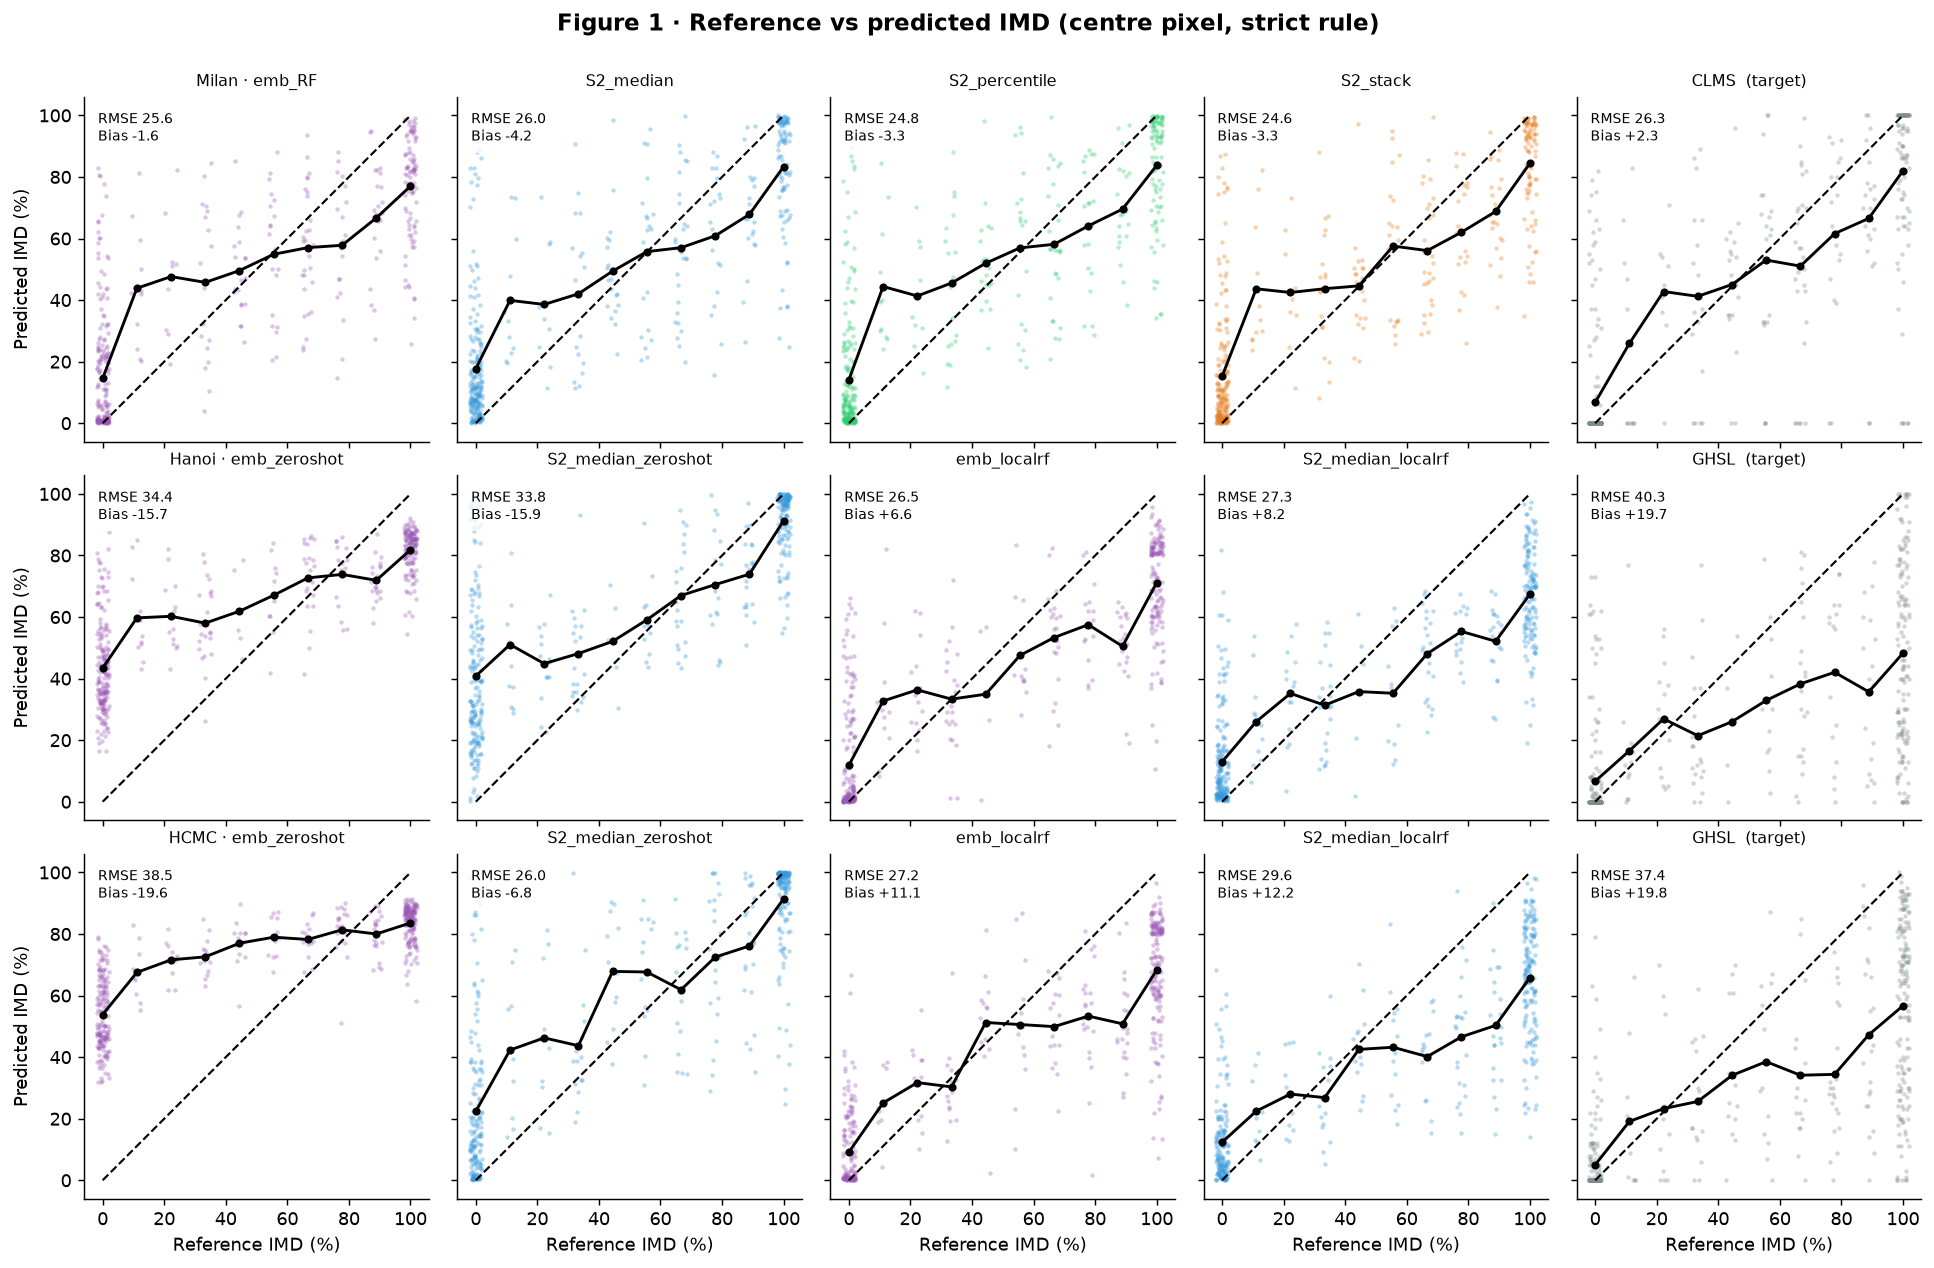

Figure 1 saved.


In [32]:
def _map_color(map_id, city):
    fs = _meta[(_meta.city == city) & (_meta.map_id == map_id)]['feature_set'].iloc[0]
    return MAP_COLORS[fs]

def _city_maps(city):
    return [m['map_id'] for m in MAP_REGISTRY if m['city'] == city]


# ── Figure 1 · reference vs predicted ────────────────────────────────────────
# The reference takes only 10 values, so raw points stack into vertical stripes.
# Jitter reveals density; the heavy line is the per-level mean prediction.
ncol = max(len(_city_maps(c)) for c in CITIES)
fig, axes = plt.subplots(len(CITIES), ncol, figsize=(3.0 * ncol, 3.2 * len(CITIES)),
                         sharex=True, sharey=True)
jrng = np.random.default_rng(RANDOM_STATE)

for i, city in enumerate(CITIES):
    maps = _city_maps(city)
    for j in range(ncol):
        ax = axes[i, j]
        if j >= len(maps):
            ax.axis('off')
            continue
        map_id = maps[j]
        g = strict[(strict.city == city) & (strict.map_id == map_id)].dropna(
            subset=['pred_imd'])
        jitter = jrng.uniform(-2, 2, len(g))
        ax.scatter(g['ref_imd'] + jitter, g['pred_imd'], s=6, alpha=0.35,
                   linewidths=0, color=_map_color(map_id, city))
        lvl = g.groupby('ref_level')['pred_imd'].mean()
        ax.plot(lvl.index * 100 / 9, lvl.values, '-o', color='black', lw=1.6, ms=3.5)
        ax.plot([0, 100], [0, 100], 'k--', lw=1.2)
        row = table1[(table1.city == city) & (table1.map_id == map_id)].iloc[0]
        ax.text(0.04, 0.96, f'RMSE {row.RMSE:.1f}\nBias {row.Bias:+.1f}',
                transform=ax.transAxes, va='top', fontsize=8,
                bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
        ax.set_xlim(-6, 106); ax.set_ylim(-6, 106); ax.set_aspect('equal')
        ttl = f'{map_id}' + ('  (target)' if row.role == 'ceiling' else '')
        ax.set_title(f'{city} · {ttl}' if j == 0 else ttl, fontsize=9)
        if j == 0: ax.set_ylabel('Predicted IMD (%)')
        if i == len(CITIES) - 1: ax.set_xlabel('Reference IMD (%)')

fig.suptitle('Figure 1 · Reference vs predicted IMD (centre pixel, strict rule)',
             fontsize=13, fontweight='bold', y=1.005)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig01_scatter_grid.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 1 saved.')

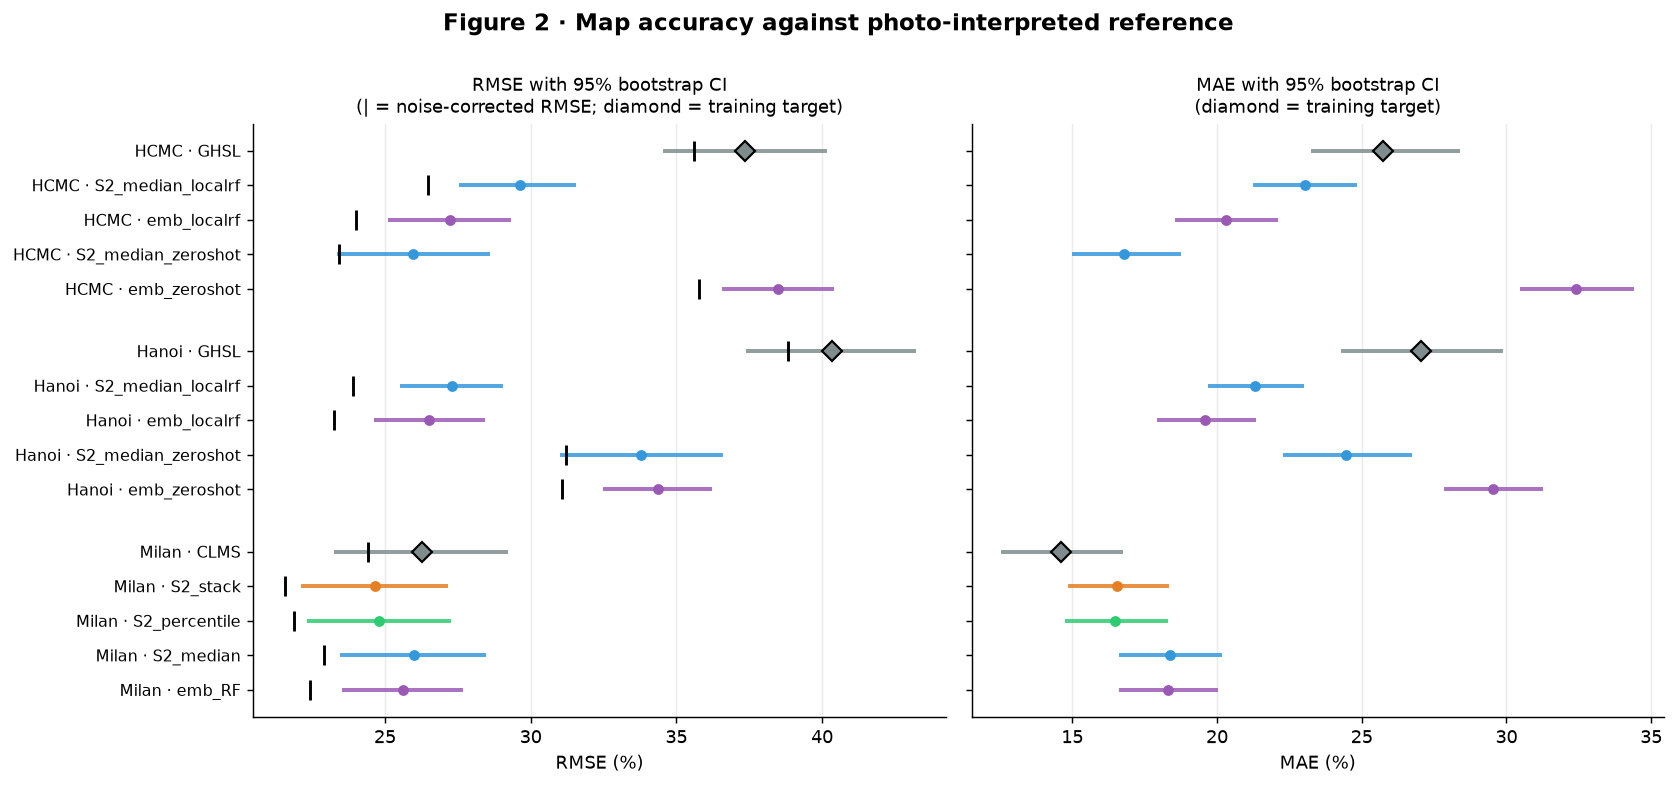

Figure 2 saved.


In [33]:
# ── Figure 2 · forest plot with bootstrap CIs ────────────────────────────────
# The headline figure: overlapping whiskers make the indistinguishability
# argument instantly, where a column of numbers invites ranking the 3rd decimal.
fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharey=True)

lab, ypos, y = [], [], 0
for city in CITIES:
    for map_id in _city_maps(city):
        lab.append(f'{city} · {map_id}')
        ypos.append(y); y += 1
    y += 0.8                                     # gap between cities

for ax, (stat, lo, hi) in zip(axes, [('RMSE', 'RMSE_lo', 'RMSE_hi'),
                                     ('MAE', 'MAE_lo', 'MAE_hi')]):
    k = 0
    for city in CITIES:
        for map_id in _city_maps(city):
            r = table1_ci[(table1_ci.city == city) &
                          (table1_ci.map_id == map_id)].iloc[0]
            ceiling = r.role == 'ceiling'
            ax.plot([r[lo], r[hi]], [ypos[k]] * 2, '-',
                    color=_map_color(map_id, city), lw=2.2, alpha=0.85)
            ax.plot(r[stat], ypos[k], 'D' if ceiling else 'o',
                    color=_map_color(map_id, city), ms=8 if ceiling else 6,
                    markeredgecolor='black' if ceiling else 'none', mew=1.2)
            if stat == 'RMSE':                   # noise-corrected marker
                ax.plot(r['RMSE_corr'], ypos[k], '|', color='black', ms=11, mew=1.6)
            k += 1
    ax.set_yticks(ypos); ax.set_yticklabels(lab, fontsize=9)
    ax.invert_yaxis(); ax.grid(axis='x', alpha=0.25)
    ax.set_xlabel(f'{stat} (%)')
    ax.set_title(f'{stat} with 95% bootstrap CI'
                 + ('\n(| = noise-corrected RMSE; diamond = training target)'
                    if stat == 'RMSE' else '\n(diamond = training target)'),
                 fontsize=10)

fig.suptitle('Figure 2 · Map accuracy against photo-interpreted reference',
             fontsize=13, fontweight='bold', y=1.0)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig02_forest_ci.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 2 saved.')

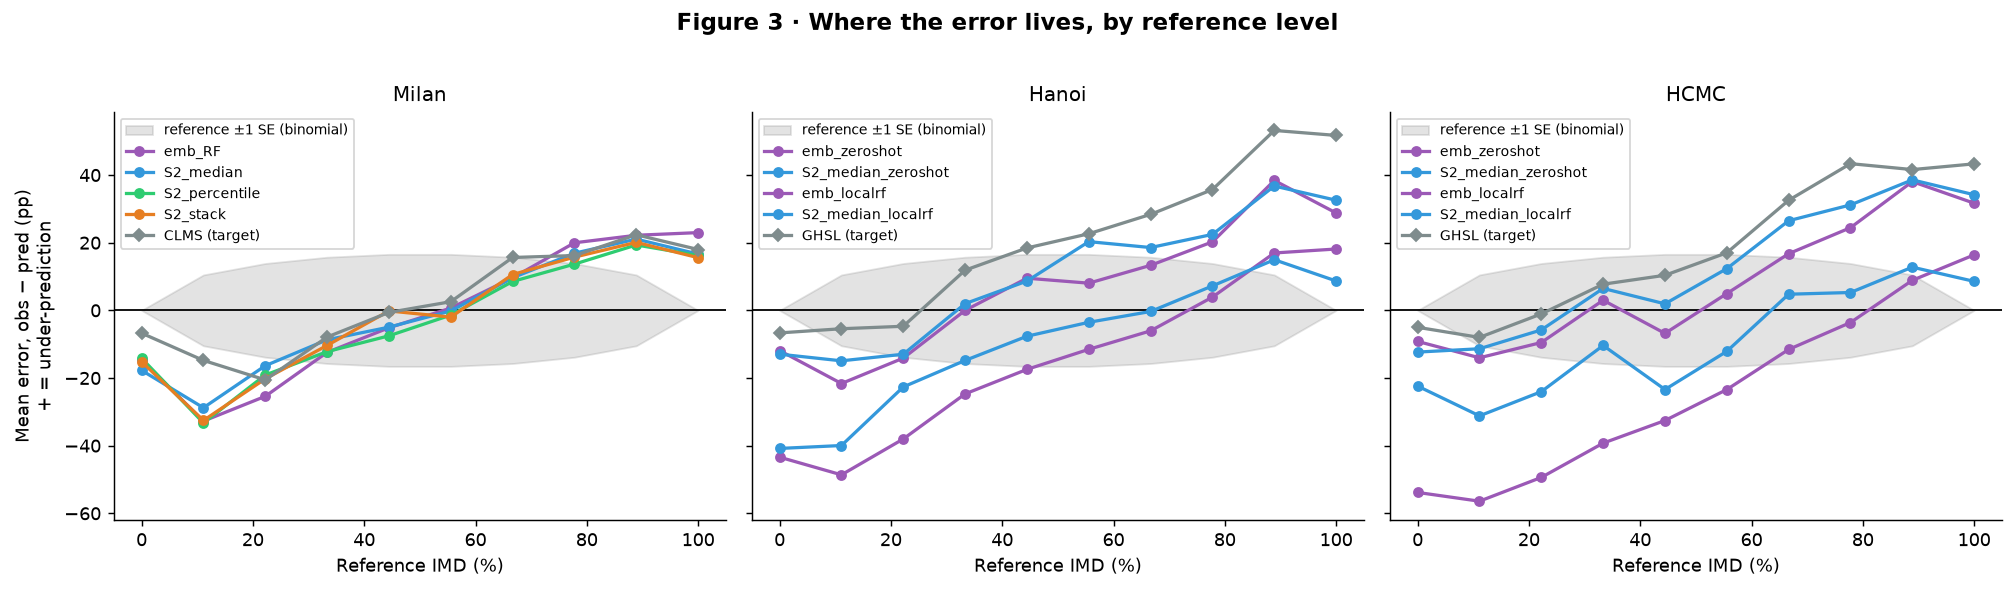

Figure 3 saved.


In [34]:
# ── Figure 3 · signed error by reference level ───────────────────────────────
# Shows WHERE the error lives, with the binomial +/-1 SE envelope behind it so
# the share the reference itself could explain is visible.
fig, axes = plt.subplots(1, len(CITIES), figsize=(5.2 * len(CITIES), 4.4), sharey=True)

lv = np.arange(10)
lv_pct = lv * 100 / 9
se = 100 * np.sqrt((lv_pct / 100) * (1 - lv_pct / 100) / 9)

for ax, city in zip(axes, CITIES):
    ax.fill_between(lv_pct, -se, se, color='grey', alpha=0.22, zorder=0,
                    label='reference $\\pm$1 SE (binomial)')
    ax.axhline(0, color='black', lw=1.0, zorder=1)
    for map_id in _city_maps(city):
        g = strict[(strict.city == city) & (strict.map_id == map_id)]
        mean_err = g.groupby('ref_level')['error'].mean()
        r = table1[(table1.city == city) & (table1.map_id == map_id)].iloc[0]
        ax.plot(mean_err.index * 100 / 9, mean_err.values,
                '-D' if r.role == 'ceiling' else '-o',
                color=_map_color(map_id, city), lw=1.8, ms=5,
                label=map_id + (' (target)' if r.role == 'ceiling' else ''))
    ax.set_title(city); ax.set_xlabel('Reference IMD (%)')
    ax.legend(fontsize=7.5, loc='upper left')
axes[0].set_ylabel('Mean error, obs $-$ pred (pp)\n$+$ = under-prediction')

fig.suptitle('Figure 3 · Where the error lives, by reference level',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig03_error_by_level.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 3 saved.')

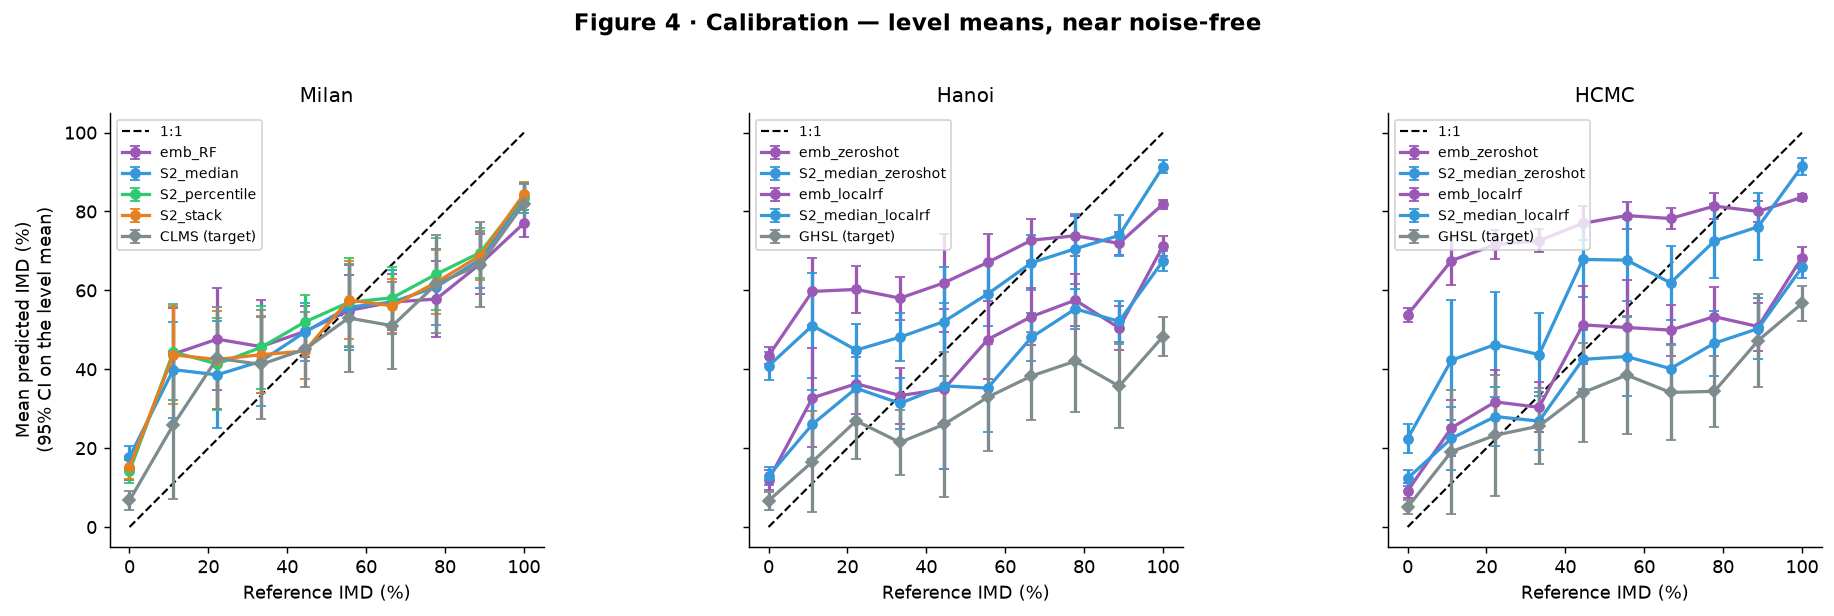

Figure 4 saved.


In [35]:
# ── Figure 4 · calibration ───────────────────────────────────────────────────
# Averaging ~45 plots per level shrinks reference noise from ~17pp to ~2pp, so
# this is the one view where map bias is visible almost noise-free.
fig, axes = plt.subplots(1, len(CITIES), figsize=(5.2 * len(CITIES), 4.6), sharey=True)

for ax, city in zip(axes, CITIES):
    ax.plot([0, 100], [0, 100], 'k--', lw=1.2, label='1:1')
    for map_id in _city_maps(city):
        g = (strict[(strict.city == city) & (strict.map_id == map_id)]
             .dropna(subset=['pred_imd']))
        agg = g.groupby('ref_level')['pred_imd'].agg(['mean', 'sem', 'count'])
        r = table1[(table1.city == city) & (table1.map_id == map_id)].iloc[0]
        ax.errorbar(agg.index * 100 / 9, agg['mean'], yerr=1.96 * agg['sem'],
                    fmt='-D' if r.role == 'ceiling' else '-o',
                    color=_map_color(map_id, city), lw=1.8, ms=5, capsize=2.5,
                    label=map_id + (' (target)' if r.role == 'ceiling' else ''))
    ax.set_xlim(-5, 105); ax.set_ylim(-5, 105); ax.set_aspect('equal')
    ax.set_title(city); ax.set_xlabel('Reference IMD (%)')
    ax.legend(fontsize=7.5, loc='upper left')
axes[0].set_ylabel('Mean predicted IMD (%)\n(95% CI on the level mean)')

fig.suptitle('Figure 4 · Calibration — level means, near noise-free',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig04_calibration.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 4 saved.')

---
## Cell 14 · Conclusions

*(Numbers below are printed by the summary cell; read them together with the tables.)*

**1 · The Milan variants are statistically indistinguishable.** All four sit within
~1.4 RMSE of each other, and their bootstrap CIs overlap heavily. Table 2's
FDR-corrected paired tests are the formal statement; where a pair does reach
significance, read `median_dABS` next to it — with n = 450, sub-percentage-point
differences can be significant and still meaningless.

**2 · The training target is the ceiling.** CLMS — the product every Milan model was
fitted to reproduce — scores no better against photo-interpretation than the models
do. The models have essentially reached the information content of their labels;
further gains would require better labels, not better features or estimators.

**3 · The reference contributes a large, quantifiable share of the error.** A 9-cell
reference carries up to 16.7 pp of binomial sampling noise. Removing it drops RMSE by
roughly 3 points without reordering anything. Because sub-cells within a 10 m pixel
are spatially correlated, the true reference noise is larger still, so the corrected
figure remains an **upper bound** on map error.

**4 · The conclusion does not depend on the impervious coding.** Rules B and C move
absolute RMSE but leave the ranking essentially intact (Table 3).

**5 · In Vietnam the models beat their own training target.** GHSL scores RMSE ~40
(Hanoi) and ~37 (HCMC) — worst or second-worst in both cities — with bias ≈ +20,
meaning it *understates* imperviousness by about 20 points relative to what an
interpreter sees. Every locally-retrained model, and in HCMC the S2-median zero-shot
map, beats it.

This partly reframes `02_Transferability_Vietnam_v2.ipynb`. That notebook scored
zero-shot transfer against GHSL and measured bias −24.9 (Hanoi); against independent
interpretation the same maps show −15.7. Some of the apparent transfer failure is
GHSL reference error rather than model error. The ranking also changes: against GHSL
local retraining wins everywhere, but against interpretation **S2-median zero-shot is
the single best HCMC map**, ahead of both local models. Local retraining still clearly
wins in Hanoi.

Treat the Vietnam conclusions of `02` as conditional on GHSL, and prefer these
numbers where the two disagree.

### Caveats

- **Single interpreter, no agreement estimate.** An unquantified share of the
  residual is reference error, not map error. A second interpreter on a subset would
  bound it.
- **The noise correction is a plug-in estimator** using the prediction for the
  unknown true *p*, and assumes independent sub-cells. Both make it conservative.
- **Plot geolocation is assumed exact.** A half-pixel offset at 10 m would inflate
  error most in heterogeneous areas — consistent with the observed mid-range spread.
- **These are 450 plots per city**, stratified by the map product being tested. The
  strata are balanced by design, so metrics are *not* area-weighted and should not be
  read as city-wide accuracy.

In [36]:
# ── Run manifest, matching the model_metadata_* / transfer_summary convention ──
try:
    _commit = subprocess.check_output(['git', 'rev-parse', 'HEAD'],
                                      stderr=subprocess.DEVNULL).decode().strip()
except Exception:
    _commit = None

summary = {
    'notebook':      '04_Validation_PhotoInterpreted.ipynb',
    'run_date':      datetime.datetime.now().isoformat(timespec='seconds'),
    'git_commit':    _commit,
    'reference':     'photo-interpreted 3x3 sub-cell grid, 10m unit area, 2018 imagery',
    'geometry':      'one plot (10m x 10m) = one map pixel; centre-pixel sampling',
    'n_plots':       {c: int(len(g)) for c, g in plot_gdfs.items()},
    'impervious_rules': {k: sorted(v) for k, v in RULES.items()},
    'dropped_codes': sorted(DROP_CODES),
    'primary_rule':  'strict',
    'bootstrap':     {'n_boot': N_BOOT, 'seed': RANDOM_STATE, 'unit': 'plot',
                      'shared_index_per_city': True},
    'multiple_comparison': {'method': 'benjamini-hochberg', 'family': 'within city',
                            'alpha': ALPHA},
    'registry':      MAP_REGISTRY,
    'sampling_audit': audit_df.to_dict('records'),
    'headline':      table1_ci[['city', 'map_id', 'role', 'N', 'RMSE', 'RMSE_lo',
                                'RMSE_hi', 'RefNoise', 'RMSE_corr', 'MAE', 'Bias',
                                'r', 'R2']].round(4).to_dict('records'),
}
with open(f'{OUTPUT_DIR}/validation_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print('Saved validation_summary.json')
print('\nOutputs in', OUTPUT_DIR)
for _f in sorted(os.listdir(OUTPUT_DIR)):
    print('  ', _f)

Saved validation_summary.json

Outputs in ./outputs_validation
   fig01_scatter_grid.png
   fig02_forest_ci.png
   fig03_error_by_level.png
   fig04_calibration.png
   table1_headline_ci.csv
   table2_wilcoxon_pairs.csv
   table3_rule_sensitivity.csv
   table4_perlevel_metrics.csv
   table4b_perclass7_metrics.csv
   validation_per_plot_long.csv
   validation_summary.json
